# Model

In [ ]:
from topological_insulator import Problem

structure_path = "../../../../../topological_insulator/data/structures/"
structure_name = "kagome.json"
material_path = "../../../../../topological_insulator/data/cases/"
material_name = "graphene.json"

problem = Problem(structure_path=structure_path, structure_name=structure_name,
                #   material_path=material_path, material_name=material_name
)

In [ ]:
subs = ["A", "B", "C"]
for sub_label in subs:
    parser = getattr(problem.cell_parser.eigenvalues, sub_label).value
    for nn_label in subs:
        try:
            parser["nn_hopping"][nn_label]["t_ss_sigma"] = -1
        except:
            pass
        try:
            parser["kane_mele_soc"][nn_label]["lambda_ss"] = -0.1
        except:
            pass
    print(parser)

{'onsite_energy': {'A': {'E_s': 0, 'E_p': 0}}, 'nn_hopping': {'B': {'t_ss_sigma': -1, 't_sp_sigma': 0, 't_pp_sigma': 0, 't_pp_pi': 0, 'delta_heavy': 0, 'delta_light': 0}, 'C': {'t_ss_sigma': -1, 't_sp_sigma': 0, 't_pp_sigma': 0, 't_pp_pi': 0, 'delta_heavy': 0, 'delta_light': 0}}, 'kane_mele_soc': {'A': {'lambda_ss': -0.1, 'lambda_sp': 0, 'lambda_pp': 0}, 'B': {'lambda_ss': -0.1, 'lambda_sp': 0, 'lambda_pp': 0}, 'C': {'lambda_ss': -0.1, 'lambda_sp': 0, 'lambda_pp': 0}}, 'chadi_soc': {'A': {'Delta_ss': 0, 'Delta_sp': 0, 'Delta_pp': 0}}, 'interaction': {'A': {'U_s': 0, 'U_p': 0, 'n_s_up': 0, 'n_s_down': 0, 'n_px_up': 0, 'n_px_down': 0, 'n_py_up': 0, 'n_py_down': 0, 'n_pz_up': 0, 'n_pz_down': 0}}}
{'onsite_energy': {'B': {'E_s': 0, 'E_p': 0}}, 'nn_hopping': {'A': {'t_ss_sigma': -1, 't_sp_sigma': 0, 't_pp_sigma': 0, 't_pp_pi': 0, 'delta_heavy': 0, 'delta_light': 0}, 'C': {'t_ss_sigma': -1, 't_sp_sigma': 0, 't_pp_sigma': 0, 't_pp_pi': 0, 'delta_heavy': 0, 'delta_light': 0}}, 'kane_mele_soc':

In [3]:
location = "bulk"
problem.setup(
    N_r = 16, # size of lattice in real space
    N_k = 400, # reciprocal space discretization
    location = location,
    BZ="reduced",
    dangling_bonds = True
)

Building Geometry...
Geometry - Done.
Building 'Bulk' Hamiltonian...
'Bulk' Hamiltonian - Done.


In [4]:
g = problem.geometry
tb_bulk = problem.hamiltonian["bulk"]["tight_binding"]

In [5]:
problem.run(
    H_type="reciprocal"
)

Calculating 'Bulk' Eigenvalues...
'Bulk' Eigenvalues - Done!


## Total Band Structure

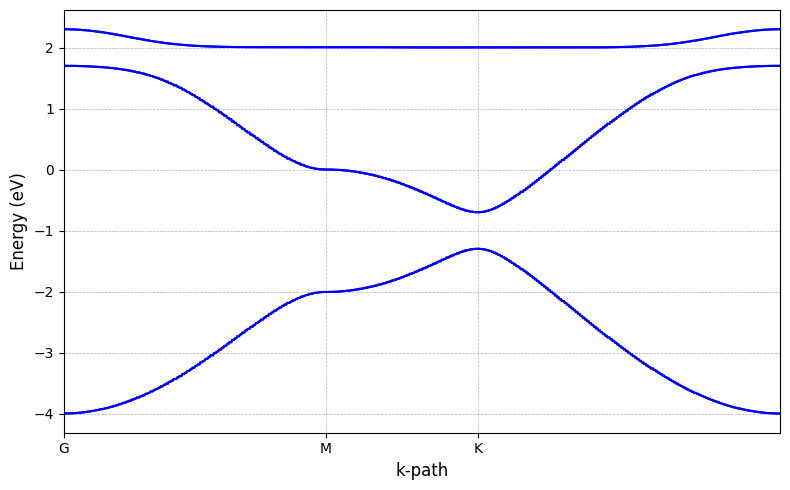

In [ ]:
tb_bulk.plot_band_structure(g)

# Z2 Invariant

In [41]:
bands= [0, 1, 21, 20]
wf = problem.hamiltonian["bulk"]["topological_invariants"]
Z_2 = wf.Z2_invariant(bands=bands)
print("")
print(f"Z2 = {Z_2}")

Calculating Z2 Invariant...
Z2 Invariant - Done!

Z2 = 1


In [ ]:

from pfapack import pfaffian as pf
O = tb_bulk.O # Time-Reversal Operator
U_k = tb_bulk.U_k_dict
kx, ky = g.kx_bulk, g.ky_bulk
trims = g.trims
deltas = []
delta_dict = {}
for k in trims:
    i = np.argmin(np.abs(g.kx_bulk - k[0]))
    j = np.argmin(np.abs(g.ky_bulk - k[1]))
    key = f"[{kx[i]}, {ky[j]}]"
    u_k = U_k[key][:, bands]
    w_k = u_k.conj().T @ O @ u_k.conj()
    w_k_det = np.linalg.det(w_k)
    P_k = pf.pfaffian(w_k)
    delta_i = np.sqrt(w_k_det) / P_k
    deltas.append(np.sign(delta_i.real))
    delta_dict[f"{k}"] = delta_i
total_product = np.prod(deltas)
Z_2 = int((1 - total_product) / 2) # maps +1 to 0, −1 to 1
delta_dict

{'[0. 0.]': np.complex128(-0.9999999999999999+4.986202206141625e-18j),
 '[ 1.57079633 -0.90689968]': np.complex128(-1-6.348318557701433e-17j),
 '[0.         1.81379936]': np.complex128(-1-0j),
 '[1.57079633 0.90689968]': np.complex128(1+0j)}